In [1]:
import armbnfmentorer.vaps.bnfradsys43m60sS10c1 as bnfvap43

In [2]:
path_in = '/Volumes/stu3data2/bnf_radsys_data/bnfradsys43m60sS10.b1/'#'/Users/htelg/data/arm/archive/bnf/bnfradsys43m60sS10.b1/'
path_out = '~/tmp/bnfradsys43m60sS10.c1/{version}/'#'/Users/htelg/data/arm/vap/bnfradsys43m60sS10.c1/{version}/'
radflux_parameters_db = 'bnfvap.db'
reporter = None

In [3]:
vapi = bnfvap43.BnfRadsys43m60sS10C1(p2fld_in = path_in,
                                     p2fld_out = path_out, 
                                     date_from_name = lambda name: pd.to_datetime(name.split('.')[2]),
                                     output_file_format = 'bnfradsys43m60sS10.c1.{date}.nc',
                                     radflux_parameters_db = 'bnfvap.db', 
                                    verbose = True)
self = vapi

start time: 2026-06-25 15:48:48.894108
Get all files in /Volumes/stu3data2/bnf_radsys_data/bnfradsys43m60sS10.b1 with glob pattern: *.nc


In [4]:
vapi.workplan

,p2f_in,p2f_out
2025-01-30,/Volumes/stu3data2/bnf_radsys_data/bnfradsys43...,~/tmp/bnfradsys43m60sS10.c1/0.2/bnfradsys43m60...
2025-02-26,/Volumes/stu3data2/bnf_radsys_data/bnfradsys43...,~/tmp/bnfradsys43m60sS10.c1/0.2/bnfradsys43m60...
2025-03-12,/Volumes/stu3data2/bnf_radsys_data/bnfradsys43...,~/tmp/bnfradsys43m60sS10.c1/0.2/bnfradsys43m60...
2025-03-13,/Volumes/stu3data2/bnf_radsys_data/bnfradsys43...,~/tmp/bnfradsys43m60sS10.c1/0.2/bnfradsys43m60...
2025-03-14,/Volumes/stu3data2/bnf_radsys_data/bnfradsys43...,~/tmp/bnfradsys43m60sS10.c1/0.2/bnfradsys43m60...
...,...,...
2026-06-20,/Volumes/stu3data2/bnf_radsys_data/bnfradsys43...,~/tmp/bnfradsys43m60sS10.c1/0.2/bnfradsys43m60...
2026-06-21,/Volumes/stu3data2/bnf_radsys_data/bnfradsys43...,~/tmp/bnfradsys43m60sS10.c1/0.2/bnfradsys43m60...
2026-06-22,/Volumes/stu3data2/bnf_radsys_data/bnfradsys43...,~/tmp/bnfradsys43m60sS10.c1/0.2/bnfradsys43m60...
2026-06-23,/Volumes/stu3data2/bnf_radsys_data/bnfradsys43...,~/tmp/bnfradsys43m60sS10.c1/0.2/bnfradsys43m60...


In [5]:
i = 5

Original values -- nsw_exp:1.302,nsw_min: 931.7,nsw_max: 1211.9,ndr_exp: -0.612
Running clear sky tests (RADFLUX equivalent)
Running normalized global magnitude test
Running diffuse magnitude test
Running global irradiance variability test
Running normalized diffuse ratio variability test
Number of clearsky (valid) points:  136
Not enough clear sky points -> skip optimazation, keep old params


/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Time offset from midnight', ylabel='Shortwave Direct Normal\nIrradiance, calculated\n(calculated from\ndirect_horizontal and solar\nzenith angle) [W/m^2]'>)

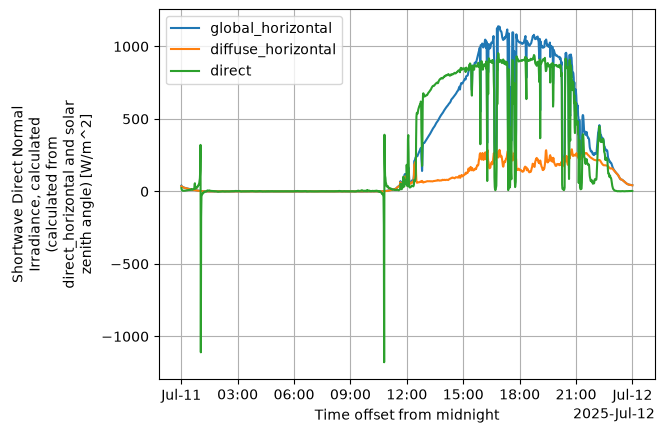

In [126]:
# i = 0
i += 1
out = vapi.process_row(iloc = i, save = False)
ds = out['ds']
bbi = out['bbi']
bbi.plot_overview()

In [12]:
self._read_previous_clearsky_parameters(self.tp_row)

{'nsw_exp': 1.202095545434091,
 'nsw_min': 800,
 'nsw_max': 1400,
 'ndr_exp': -0.6827046137686424,
 'mu0_min': 0.05,
 'diffuse_max_coeff': 150,
 'diffuse_max_exp': 0.5,
 'max_dsw_dt': 8,
 'ndr_std_max': 0.005,
 'ndr_window': 11}

In [8]:
self.tp_dropvar

['lat',
 'lon',
 'alt',
 'zenith_geometric',
 'apparent_elevation',
 'elevation',
 'equation_of_time',
 'mu0']

In [7]:
self.tp_ds

<xarray.Dataset> Size: 32kB
Dimensions:                                    (datetime: 120, bound: 2)
Coordinates:
  * datetime                                   (datetime) datetime64[ns] 960B ...
Dimensions without coordinates: bound
Data variables: (12/57)
    base_time                                  datetime64[ns] 8B ...
    time_offset                                (datetime) datetime64[ns] 960B ...
    time_bounds                                (datetime, bound) datetime64[ns] 2kB ...
    global_horizontal                          (datetime) float32 480B nan .....
    qc_down_short_hemisp                       (datetime) int32 480B ...
    down_short_hemisp_std                      (datetime) float32 480B ...
    ...                                         ...
    mu0                                        (datetime) float64 960B 0.5899...
    mask_normalized_global_magnitude           (datetime) bool 120B False ......
    mask_diffuse_magnitude                     (datetime) bool 120B False ......
    mask_global_irradiance_variability         (datetime) bool 120B False ......
    mask_normalized_diffuse_ratio_variability  (datetime) bool 120B False ......
    mask_clear_sky_shortwave_radflux           (datetime) bool 120B False ......
Attributes: (12/27)
    command_line:                radsysavg -n radsys43mavg -s bnf -f S10 --ma...
    Conventions:                 ARM-1.3
    process_version:             ingest-radsysavg-1.2-0.el9
    dod_version:                 radsys43m60s-b1-1.0
    input_datastreams:           bnfradsys43mS10.a1 : 1.0 : 20250130.170735
    site_id:                     bnf
    ...                          ...
    diffuse_max_coeff:           150
    diffuse_max_exp:             0.5
    max_dsw_dt:                  8
    ndr_std_max:                 0.005
    ndr_window:                  11
    clear_sky_params_optimized:  Not enough clear sky points

# Database check

In [18]:
import sqlite3

7

In [34]:
with sqlite3.connect(radflux_parameters_db) as conn:
    bla = pd.read_sql('select * from radflux_parameters', conn)

In [35]:
bla

,row_timestamp,input_file,output_file,processed_at,process_version,processing_server,clear_sky_params_optimized,parameters_json,nsw_exp,nsw_min,...,mu0_min,diffuse_max_coeff,diffuse_max_exp,max_dsw_dt,ndr_std_max,ndr_window,ndr_std_max_estimated,diffuse_max_coeff_estimated,diffuse_max_exp_estimated,max_dsw_dt_estimated
0,2025-03-17T00:00:00,/Volumes/stu3data2/bnf_radsys_data/bnfradsys43...,~/tmp/bnfradsys43m60sS10.c1/0.2/bnfradsys43m60...,2026-06-25T15:49:02.410097,0.2,telg-mbp.local,True,"{""diffuse_max_coeff"": 150, ""diffuse_max_coeff_...",1.196251,1152.122176,...,0.05,150.0,0.5,8.0,0.005,11.0,0.002386,100.118302,0.530008,7.827943
1,2025-03-18T00:00:00,/Volumes/stu3data2/bnf_radsys_data/bnfradsys43...,~/tmp/bnfradsys43m60sS10.c1/0.2/bnfradsys43m60...,2026-06-25T15:49:05.035120,0.2,telg-mbp.local,True,"{""diffuse_max_coeff"": 150, ""diffuse_max_coeff_...",1.183443,1141.372767,...,0.05,150.0,0.5,8.0,0.005,11.0,0.003067,99.176906,0.434527,8.488650
2,2025-03-21T00:00:00,/Volumes/stu3data2/bnf_radsys_data/bnfradsys43...,~/tmp/bnfradsys43m60sS10.c1/0.2/bnfradsys43m60...,2026-06-25T15:49:45.324049,0.2,telg-mbp.local,True,"{""diffuse_max_coeff"": 150, ""diffuse_max_coeff_...",1.199650,1160.147222,...,0.05,150.0,0.5,8.0,0.005,11.0,0.002682,111.798716,0.626386,6.890491
3,2025-03-22T00:00:00,/Volumes/stu3data2/bnf_radsys_data/bnfradsys43...,~/tmp/bnfradsys43m60sS10.c1/0.2/bnfradsys43m60...,2026-06-25T15:49:46.246172,0.2,telg-mbp.local,True,"{""diffuse_max_coeff"": 150, ""diffuse_max_coeff_...",1.179127,1092.205701,...,0.05,150.0,0.5,8.0,0.005,11.0,0.002551,123.196887,0.562429,7.420047
4,2025-03-25T00:00:00,/Volumes/stu3data2/bnf_radsys_data/bnfradsys43...,~/tmp/bnfradsys43m60sS10.c1/0.2/bnfradsys43m60...,2026-06-25T15:49:49.248998,0.2,telg-mbp.local,True,"{""diffuse_max_coeff"": 150, ""diffuse_max_coeff_...",1.194508,1053.440530,...,0.05,150.0,0.5,8.0,0.005,11.0,0.002202,103.833848,0.454161,8.298195
5,2025-03-26T00:00:00,/Volumes/stu3data2/bnf_radsys_data/bnfradsys43...,~/tmp/bnfradsys43m60sS10.c1/0.2/bnfradsys43m60...,2026-06-25T15:49:50.183311,0.2,telg-mbp.local,True,"{""diffuse_max_coeff"": 150, ""diffuse_max_coeff_...",1.240993,1092.157632,...,0.05,150.0,0.5,8.0,0.005,11.0,0.002881,130.350733,0.559303,8.082839
6,2025-04-08T00:00:00,/Volumes/stu3data2/bnf_radsys_data/bnfradsys43...,~/tmp/bnfradsys43m60sS10.c1/0.2/bnfradsys43m60...,2026-06-25T15:53:51.207634,0.2,telg-mbp.local,True,"{""diffuse_max_coeff"": 150, ""diffuse_max_coeff_...",1.246122,1000.184554,...,0.05,150.0,0.5,8.0,0.005,11.0,0.002596,153.503723,0.600032,8.810153
